In [12]:
import numpy as np
import matplotlib.pyplot as plt

## STUDY ONE AND TWO

In [42]:
participants = ('P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'P10', 'Mean')

interaction_counts = { 'Code': [5,  6, 12, 1,  15, 1,  6, 13, 4, 17],
                       'GUI':  [15, 0, 4,  2,  4,  10, 0, 5, 15, 13],
                       'AI':   [5,  7, 4,  11, 4,  4,  9, 23, 6, 7]  }

interaction_percentages = { 'Code': [8.7,  24.1, 50.5, 0.7,  20.4, 3.3,  19.6,   17.3, 27.6, 41.6],
                            'GUI':  [30.1, 0.0,  18.0, 5.7,  11.3, 60.7,  0.0,   6.5,  40.0, 20.0],
                            'AI':   [61.17, 75.9, 31.5, 93.6, 68.3, 36.0, 80.4, 76.2, 32.4, 38.4]  }


participants2 = ('P4', 'P7', 'P9', 'P10', 'Mean')

interaction_counts2 = { 'Code': [7, 54, 101, 38],
                        'GUI':  [85, 35, 58, 27],
                        'AI':   [54, 44, 16, 30]  }

interaction_times2 = { 'Code': [19.6, 136.8, 961.2, 287],
                       'GUI':  [330.7, 223.3, 194, 118.4],
                       'AI':   [1879.3, 1352, 440.7, 1455.9]  }

In [43]:
interaction_percentages2 = {}
modes = list(interaction_times2.keys())

for mode in modes:
    interaction_percentages2[mode] = []
    for participant_i in range(len(participants2) - 1):
        t = interaction_times2[mode][participant_i]
        total_t = sum(interaction_times2[m][participant_i] for m in modes)
        interaction_percentages2[mode].append(round(t / total_t * 100, 1))

for key in interaction_counts:
    vals = interaction_counts[key]
    interaction_counts[key].append(round(sum(vals) / len(vals), 1))
    vals2 = interaction_counts2[key]
    interaction_counts2[key].append(round(sum(vals2) / len(vals2), 1))

for key in interaction_percentages:
    vals = interaction_percentages[key]
    interaction_percentages[key].append(round(sum(vals) / len(vals), 1))
    vals2 = interaction_percentages2[key]
    interaction_percentages2[key].append(round(sum(vals2) / len(vals2), 1))
    

print(interaction_percentages2)

{'Code': [0.9, 8.0, 60.2, 15.4, 21.1], 'GUI': [14.8, 13.0, 12.2, 6.4, 11.6], 'AI': [84.3, 79.0, 27.6, 78.2, 67.3]}


In [49]:
interaction_counts

{'Code': [5, 6, 12, 1, 15, 1, 6, 13, 4, 17, 8.0],
 'GUI': [15, 0, 4, 2, 4, 10, 0, 5, 15, 13, 6.8],
 'AI': [5, 7, 4, 11, 4, 4, 9, 23, 6, 7, 8.0]}

In [50]:
interaction_percentages

{'Code': [8.7, 24.1, 50.5, 0.7, 20.4, 3.3, 19.6, 17.3, 27.6, 41.6, 21.4],
 'GUI': [30.1, 0.0, 18.0, 5.7, 11.3, 60.7, 0.0, 6.5, 40.0, 20.0, 19.2],
 'AI': [61.17, 75.9, 31.5, 93.6, 68.3, 36.0, 80.4, 76.2, 32.4, 38.4, 59.4]}

In [51]:
interaction_counts2

{'Code': [7, 54, 101, 38, 50.0],
 'GUI': [85, 35, 58, 27, 51.2],
 'AI': [54, 44, 16, 30, 36.0]}

In [52]:
interaction_percentages2

{'Code': [0.9, 8.0, 60.2, 15.4, 21.1],
 'GUI': [14.8, 13.0, 12.2, 6.4, 11.6],
 'AI': [84.3, 79.0, 27.6, 78.2, 67.3]}

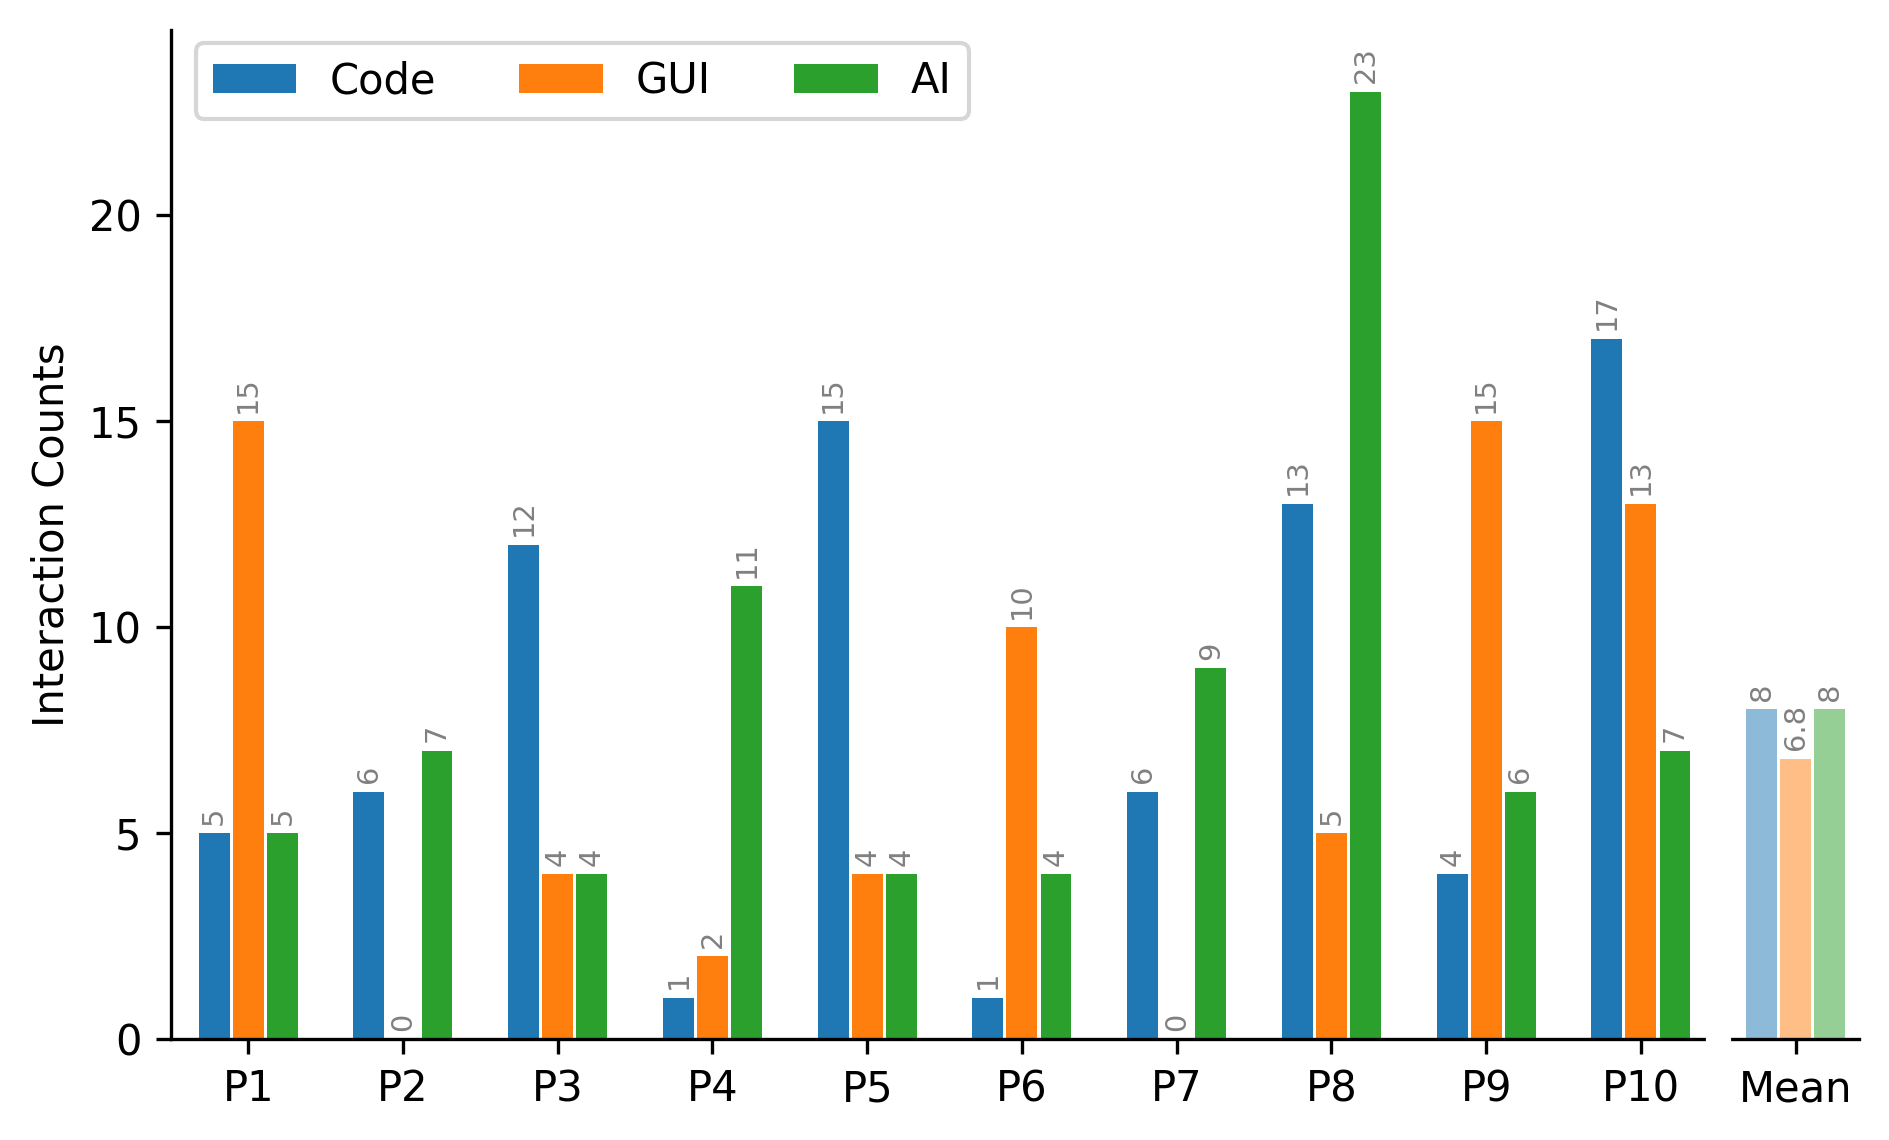

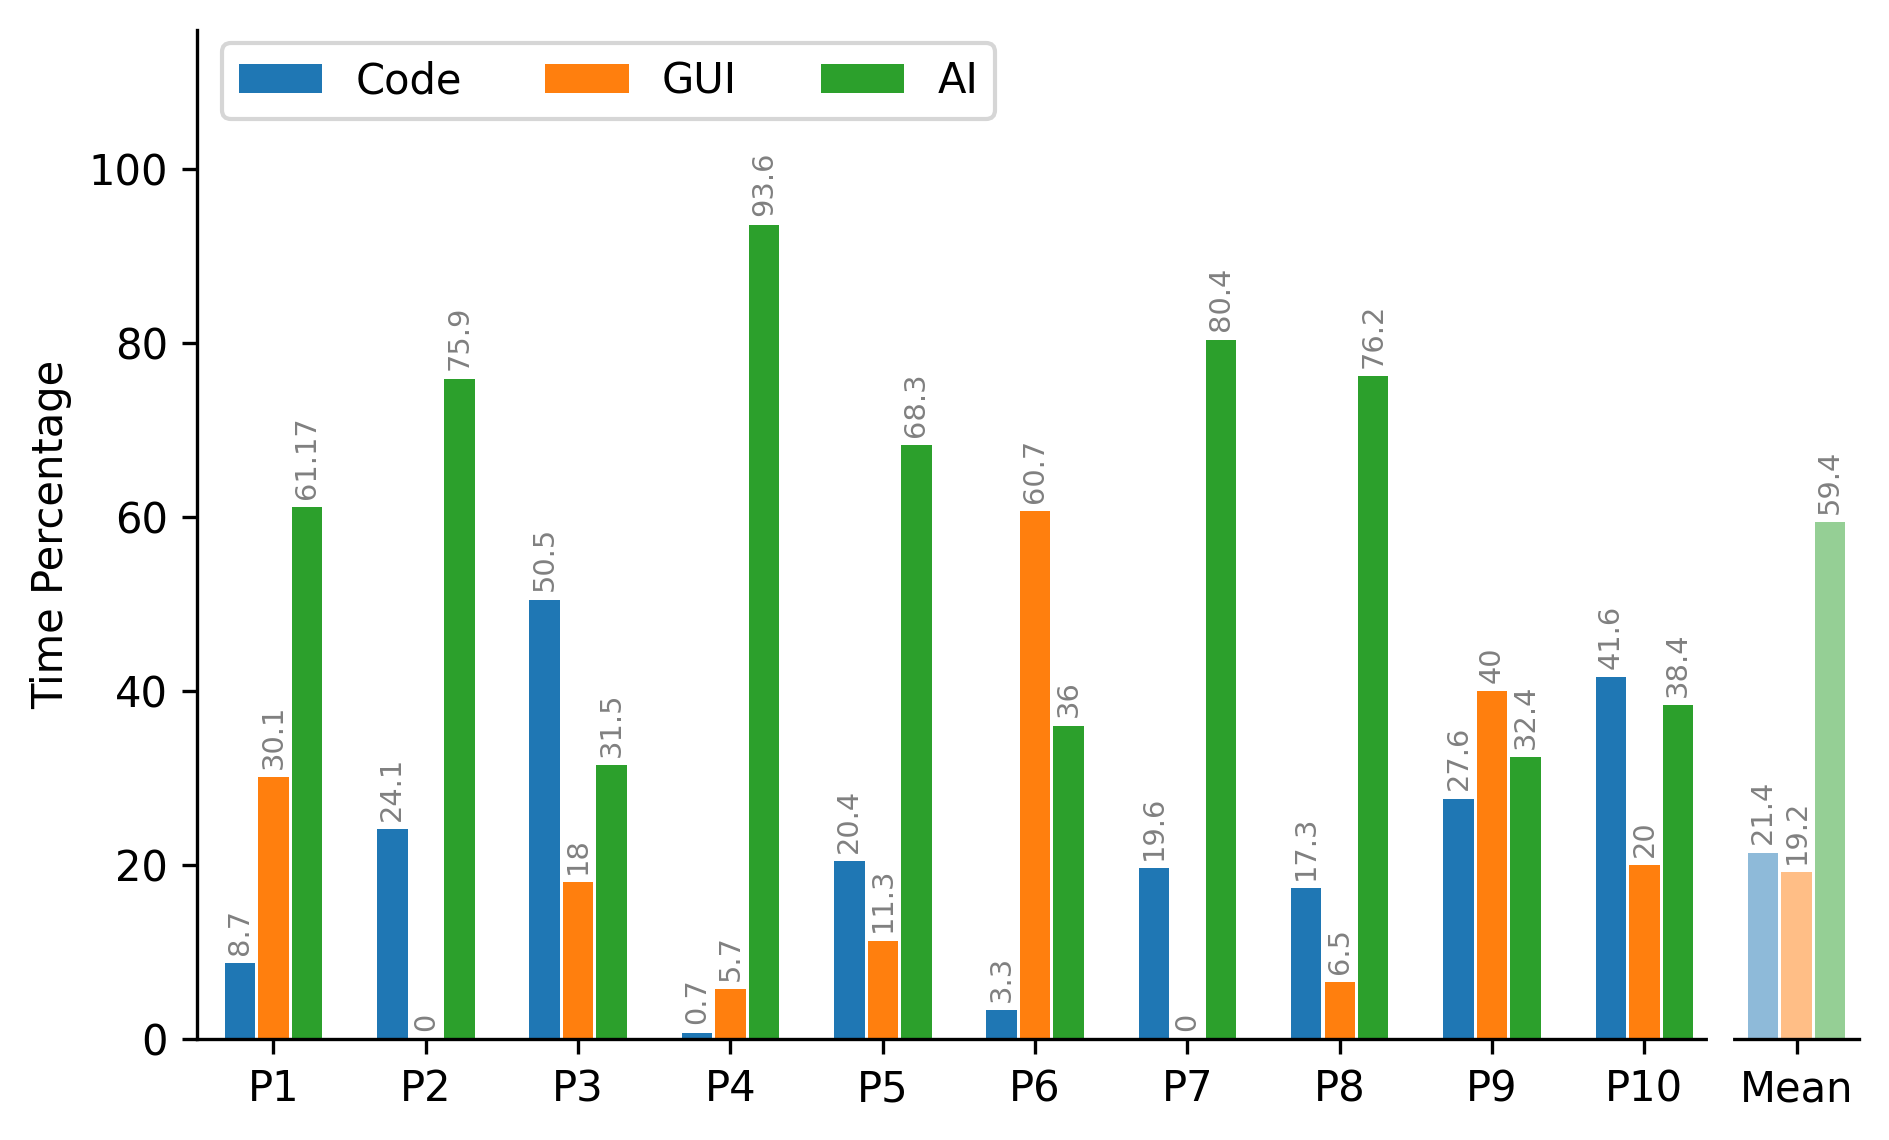

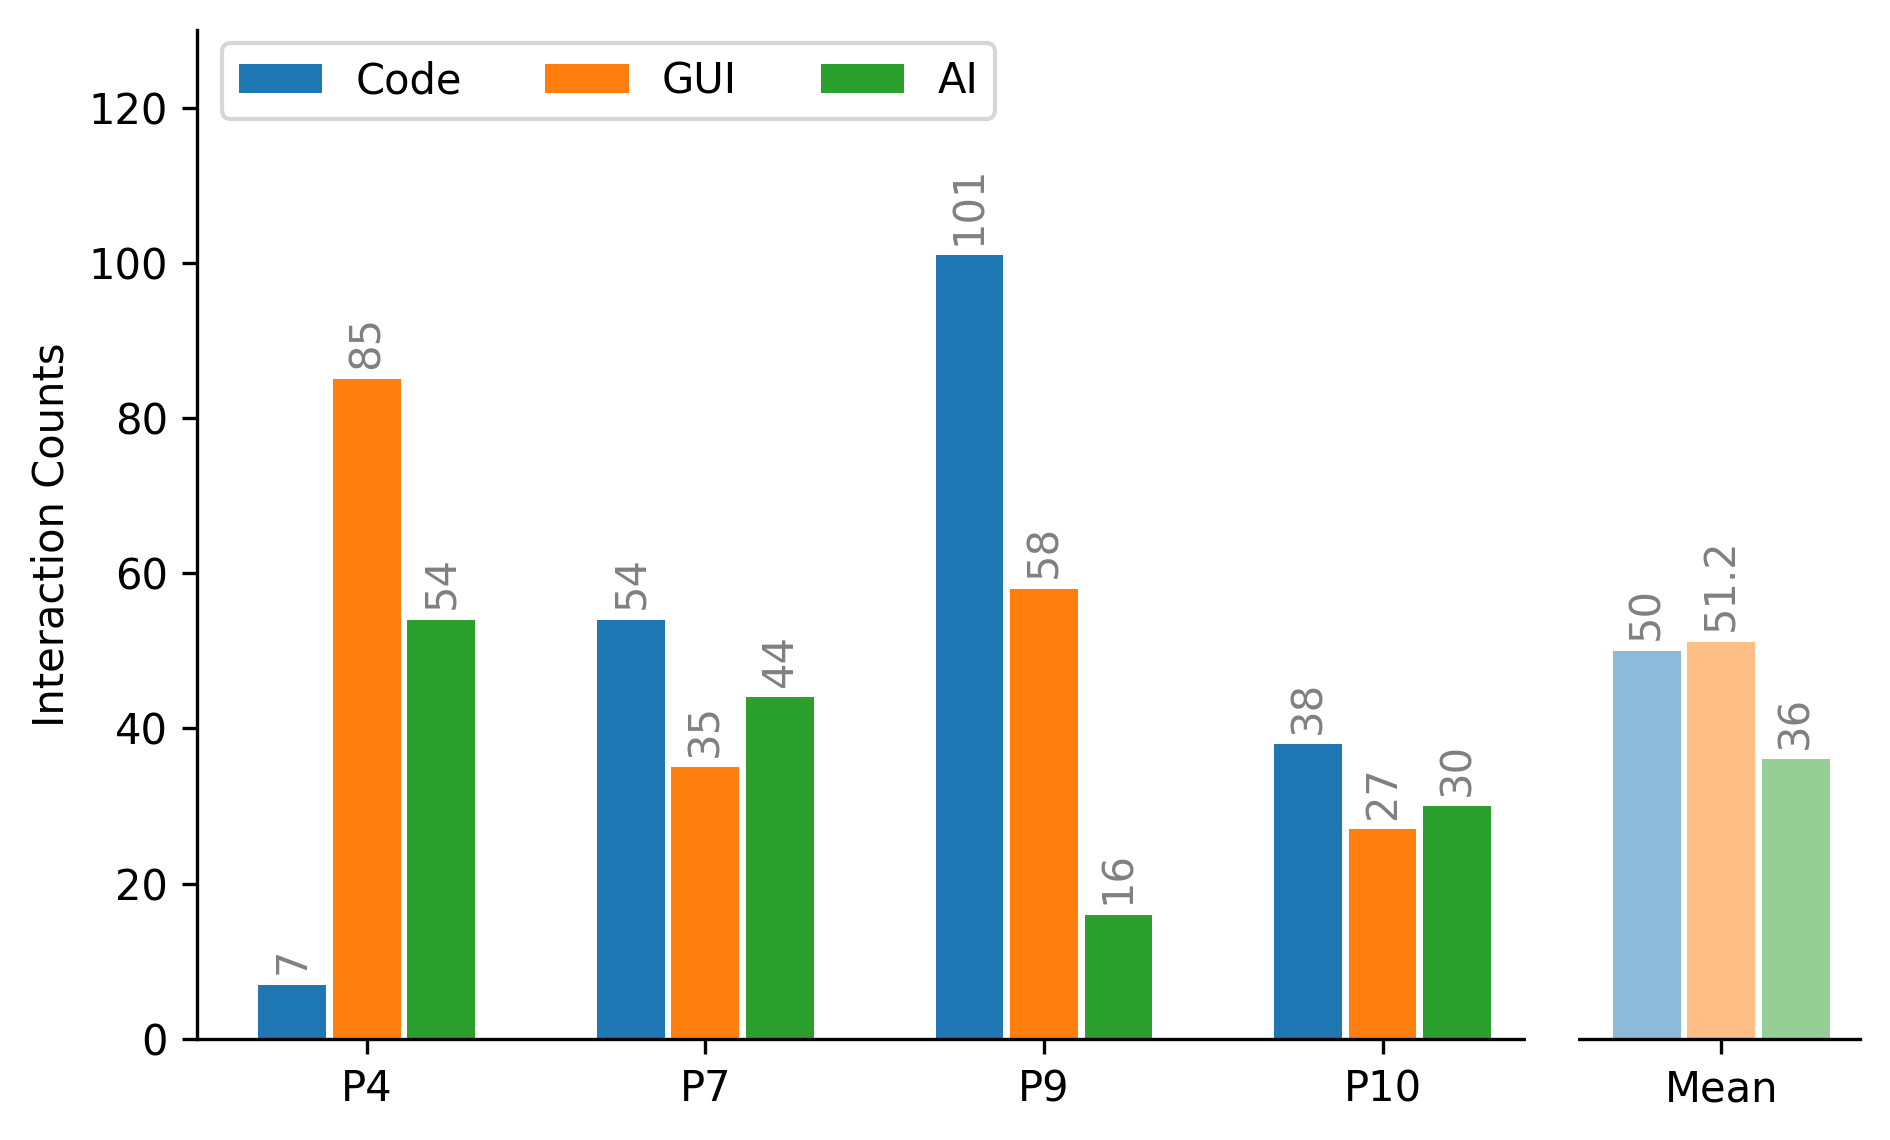

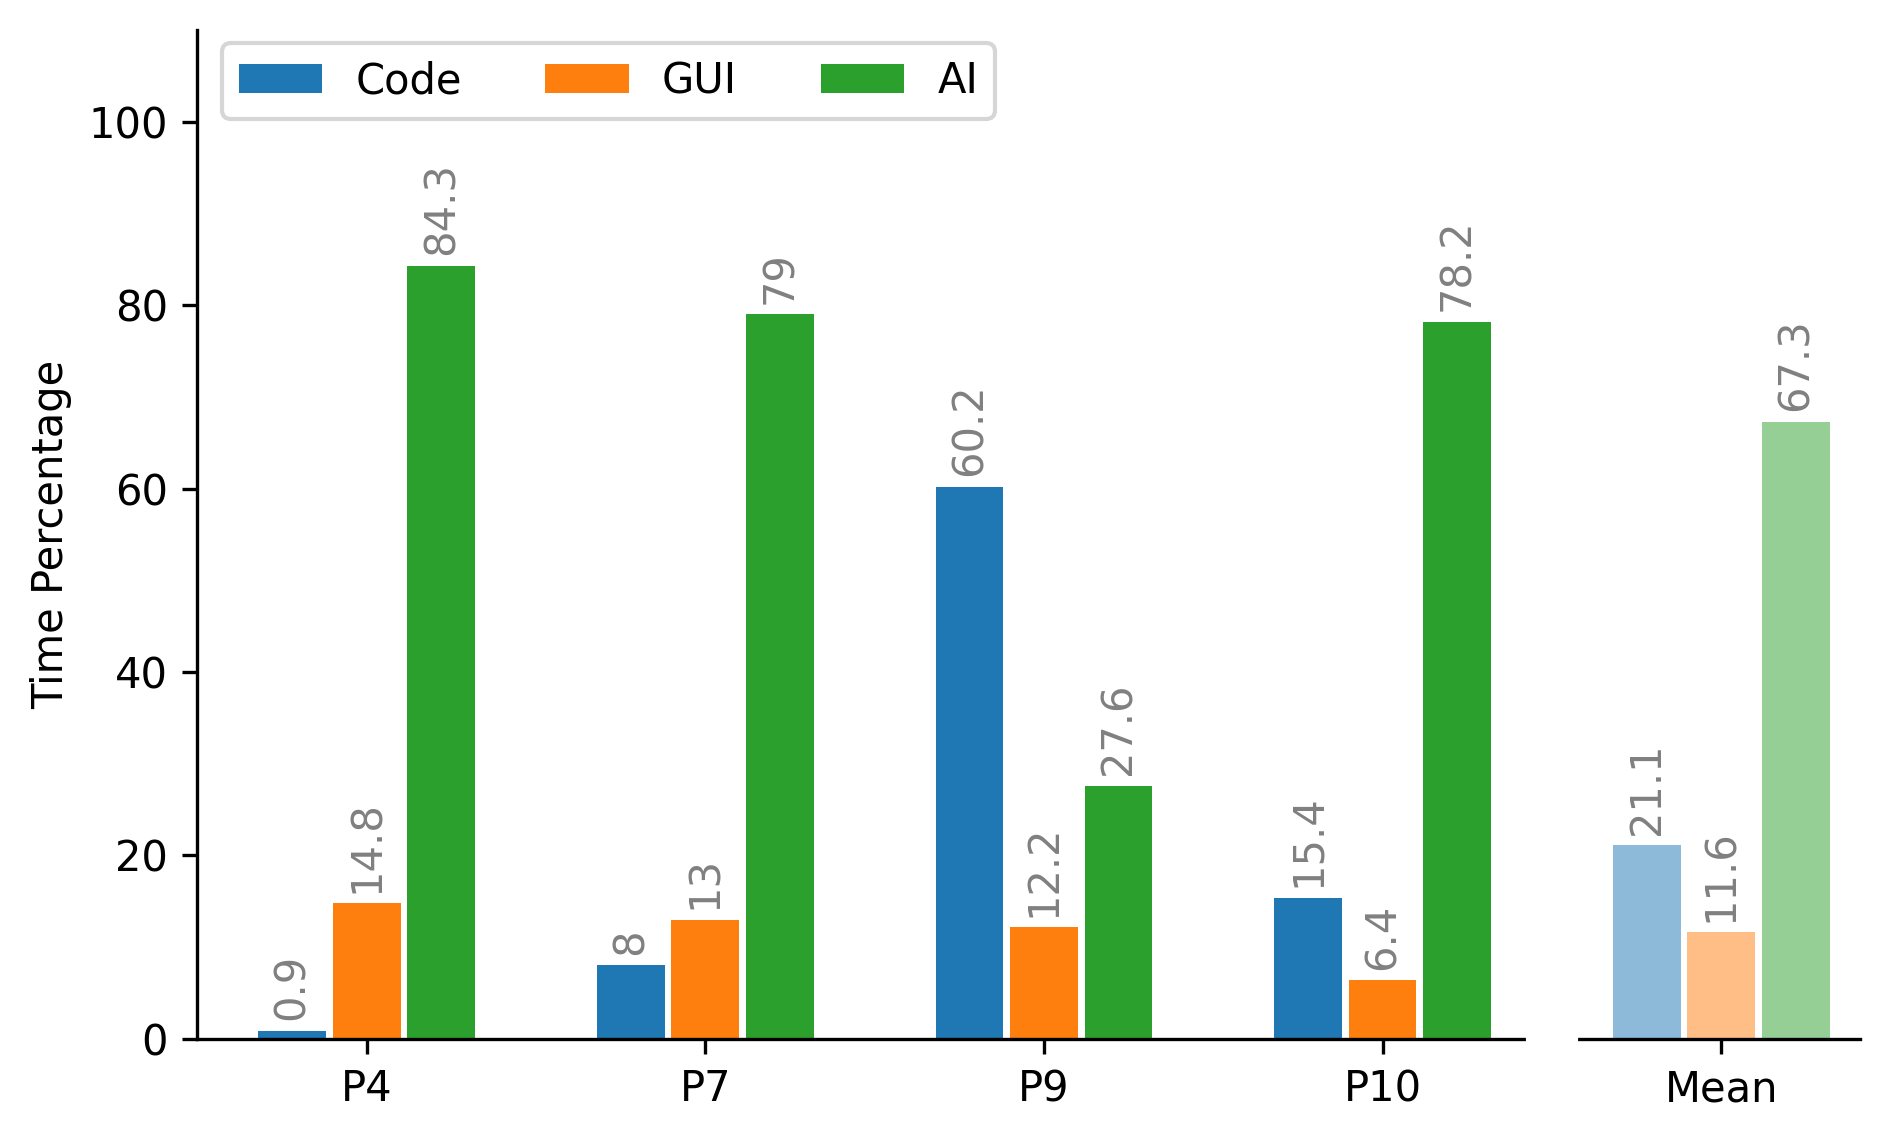

In [88]:
def bars_by_modality(data, participants, what: str, label_pad: float, label_size: float | str, ymax: float):
    fig = plt.figure(layout='tight', dpi=300, figsize=(6.4, 3.9))
    ax = fig.add_subplot(1, 1, 1)

    bars = ax.bar(np.arange(len(participants)) + -0.22, data['Code'], width=0.2)
    bars2 = ax.bar(np.arange(len(participants)), data['GUI'], width=0.2)
    bars3 = ax.bar(np.arange(len(participants)) + 0.22, data['AI'], width=0.2)

    # Did this set_alpha w/AI
    bars[-1].set_alpha(0.5)
    bars2[-1].set_alpha(0.5)
    bars3[-1].set_alpha(0.5)

    texts = ax.bar_label(bars, padding=label_pad, color=(0.5, 0.5, 0.5), fontsize=label_size, rotation='vertical')
    texts2 = ax.bar_label(bars2, padding=label_pad, color=(0.5, 0.5, 0.5), fontsize=label_size, rotation='vertical')
    texts3 = ax.bar_label(bars3, padding=label_pad, color=(0.5, 0.5, 0.5), fontsize=label_size, rotation='vertical')

    ticks = ax.set_xticks(np.arange(len(participants)), labels=participants)
    ax.set_ylabel(what)
    ax.set_ylim(bottom=0, top=ymax)

    legend = ax.legend(labels=data.keys(), loc=(0.015, 0.912), ncol=3)

    # Remove the right and top spines
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    polygon = ax.axvspan(len(participants) + -1.57, len(participants) + -1.43, ymin=-0.01, ymax=0.01, clip_on=False, color=(1.00, 1.00, 1.00), zorder=10, clip_box=None)

    ax.set_xlim(left=-0.5, right=len(participants) - 1 + 0.41)

    (plt).show()

bars_by_modality(interaction_counts, participants, 'Interaction Counts', 2, 'x-small', 24.5)
bars_by_modality(interaction_percentages, participants, 'Time Percentage', 2, 'x-small', 116)

bars_by_modality(interaction_counts2, participants2, 'Interaction Counts', 2.5, 'medium', 130)
bars_by_modality(interaction_percentages2, participants2, 'Time Percentage', 2.5, 'medium', 110)

In [31]:
# fig = plt.figure(layout='tight', dpi=200)
# ax = fig.add_subplot(1, 1, 1)

# bars = ax.bar(np.arange(len(participants)) + -0.2, interaction_counts['Code'], width=0.2)
# bars2 = ax.bar(np.arange(len(participants)), interaction_counts['GUI'], width=0.2)
# bars3 = ax.bar(np.arange(len(participants)) + 0.2, interaction_counts['AI'], width=0.2)
# texts = ax.bar_label(bars, padding=2, color=(0.5, 0.5, 0.5), fontsize='small')
# texts2 = ax.bar_label(bars2, padding=2, color=(0.5, 0.5, 0.5), fontsize='small')
# texts3 = ax.bar_label(bars3, padding=2, color=(0.5, 0.5, 0.5), fontsize='small')
# ticks = ax.set_xticks(np.arange(len(participants)), labels=participants)
# ax.set_ylabel('Interaction Count')
# text = ax.set_title('Plottery Interactions by Modality', fontweight='bold')
# ax.set_ylim(bottom=0, top=18)
# legend = ax.legend(labels=interaction_counts.keys(), loc=(0.037, 0.89), ncol=3)

# plt.show()

No figures to show. Be sure plt.show() is called within the cell.


### STUDY TWO (old, now merged with above)

In [32]:
participants = ('P4', 'P7', 'P9', 'P10', 'Mean')

interaction_counts = { 'Code': [7, 54, 101, 38],
                       'GUI':  [85, 35, 58, 27],
                       'AI':   [54, 44, 16, 30]  }

interaction_time = { 'Code': [19.6, 136.8, 961.2, 287],
                            'GUI':  [330.7, 223.3, 194, 118.4],
                            'AI':   [1879.3, 1352, 440.7, 1455.9]  }

In [33]:
time_by_participants = {}

for i in range(len(participants[:-1])):
    participant = participants[i]
    time = []
    for key in interaction_time:
        time.append(interaction_time[key][i])
    time_by_participants[participant] = time
    
time_by_participants

{'P4': [19.6, 330.7, 1879.3],
 'P7': [136.8, 223.3, 1352],
 'P9': [961.2, 194, 440.7],
 'P10': [287, 118.4, 1455.9]}

In [34]:
interaction_percentages = {'Code': [], 'GUI': [], 'AI': []}
for p in time_by_participants:
    total_time = sum(time_by_participants[p])
    for i in range(len(time_by_participants[p])):
        time = time_by_participants[p][i]
        # bad code but we don't care
        if i == 0:
            interaction_percentages['Code'].append(round(time / total_time * 100, 1))
        if i == 1:
            interaction_percentages['GUI'].append(round(time / total_time * 100, 1))
        if i == 2:
            interaction_percentages['AI'].append(round(time / total_time * 100, 1))
            
interaction_percentages

{'Code': [0.9, 8.0, 60.2, 15.4],
 'GUI': [14.8, 13.0, 12.2, 6.4],
 'AI': [84.3, 79.0, 27.6, 78.2]}

In [35]:
for key in interaction_counts:
    vals = interaction_counts[key]
    interaction_counts[key].append(round(sum(vals) / len(vals), 1))


for key in interaction_percentages:
    vals = interaction_percentages[key]
    interaction_percentages[key].append(round(sum(vals) / len(vals), 1))

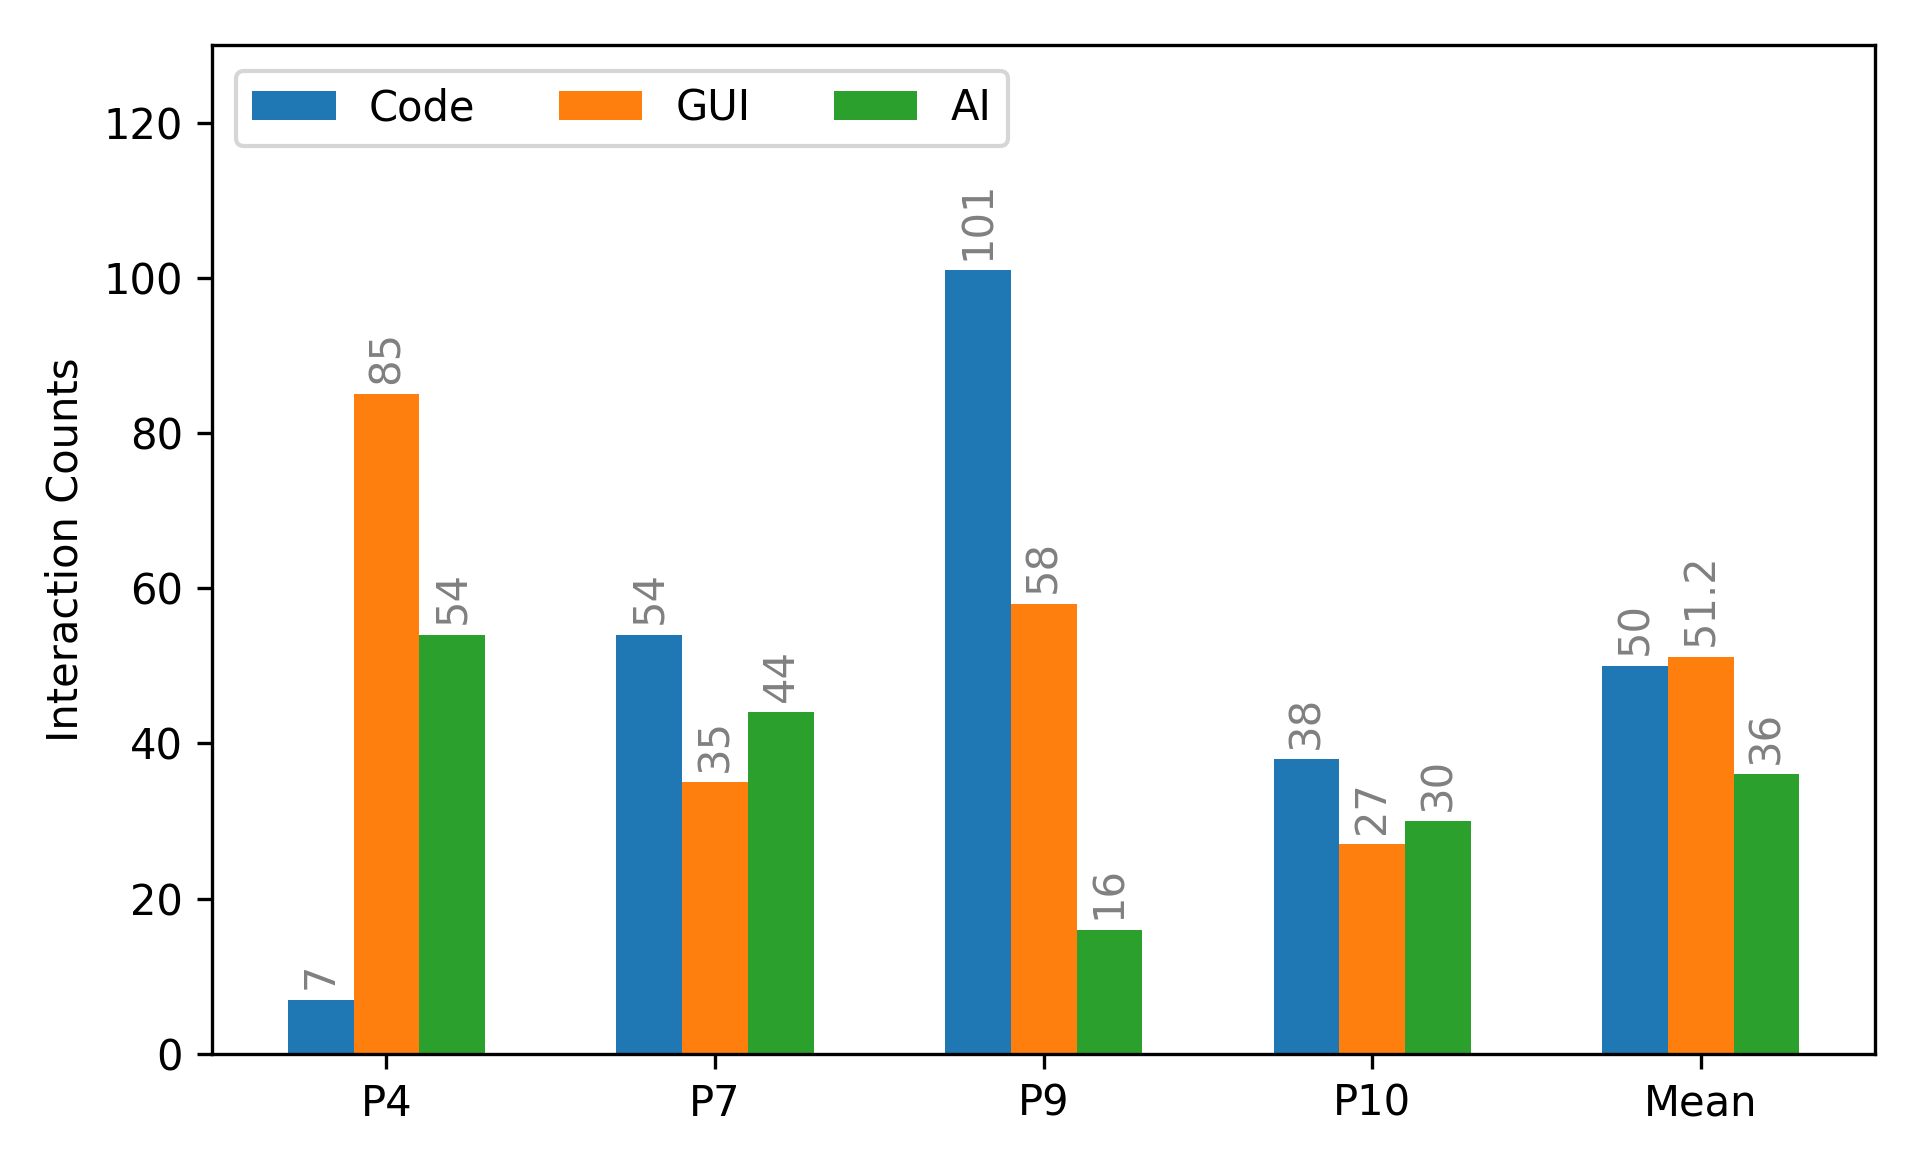

In [ ]:
def bars_by_modality(data, what : str, ymax : float):
    fig = plt.figure(layout='tight', dpi=300, figsize=(6.4, 3.9))
    ax = fig.add_subplot(1, 1, 1)

    bars = ax.bar(np.arange(len(participants)) + -0.2, data['Code'], width=0.2)
    bars2 = ax.bar(np.arange(len(participants)), data['GUI'], width=0.2)
    bars3 = ax.bar(np.arange(len(participants)) + 0.2, data['AI'], width=0.2)
    texts = ax.bar_label(bars, padding=2.5, color=(0.5, 0.5, 0.5), fontsize='medium', rotation='vertical')
    texts2 = ax.bar_label(bars2, padding=2.5, color=(0.5, 0.5, 0.5), fontsize='medium', rotation='vertical')
    texts3 = ax.bar_label(bars3, padding=2.5, color=(0.5, 0.5, 0.5), fontsize='medium', rotation='vertical')

    ticks = ax.set_xticks(np.arange(len(participants)), labels=participants)
    ax.set_ylabel(what)
    # text = ax.set_title(f'Part 2 - {what} by Modality', fontweight='bold')
    ax.set_ylim(bottom=0, top=ymax)

    legend = ax.legend(labels=data.keys(), loc=(0.014, 0.9), ncol=3)

    plt.show()

bars_by_modality(interaction_counts, 'Interaction Counts', 130)
bars_by_modality(interaction_percentages, 'Time Percentage', 110)

### Study one: AI time breakdown

In [14]:
def average(lst):
    if len(lst) == 0:
        return 0
    return sum(lst) / len(lst)

In [15]:
# typing, waiting, validating
AI_time_perc = {
    'P1': [54.76, 13.49, 31.75],
    'P2': [68.28, 15.86, 15.86],
    'P3': [70, 10, 20],
    'P4': [71.12, 11.55, 17.33],
    'P5': [72.02, 10.09, 17.89],
    'P6': [47.37, 13.16, 39.47],
    'P7': [40.91,18.75,40.34],
    'P8': [50.73, 23.27, 26],
    'P9': [66.9, 22.54, 10.56],
    'P10': [67.59, 13.79, 18.62]
}

In [16]:
avg_typing = average([AI_time_perc[k][0] for k in AI_time_perc])
print(avg_typing)
avg_waiting = average([AI_time_perc[k][1] for k in AI_time_perc])
print(avg_waiting)
avg_validating = average([AI_time_perc[k][2] for k in AI_time_perc])
print(avg_validating)

60.967999999999996
15.25
23.782000000000004


### Study two: AI time breakdown

In [17]:
AI_total = [1879.3, 1352, 440.7, 1455.9]
typing_total = [924.5, 460.3, 199.8, 821.4]
waiting_total = [330.4, 169.5, 55, 221.9]
validating_total = [657, 722.2, 185.9, 412.6]
all_dict = {'typing': typing_total, 'waiting': waiting_total, 'validating': validating_total}

In [18]:
def get_avg_by_category(category_lst, total_lst, index):
    return category_lst[index] / total_lst[index]

In [19]:
participants = ['P4', 'P7', 'P9', 'P10']
avgs = {'typing': [], 'waiting': [], 'validating': []}

for i in range(4):
    p = participants[i]
    for category in all_dict:
        category_lst = all_dict[category]
        avg = get_avg_by_category(category_lst, AI_total, i)
        avgs[category].append(avg)
        
avgs

{'typing': [0.49193848773479487,
  0.3404585798816568,
  0.45336963921034723,
  0.564187100762415],
 'waiting': [0.17581014207417656,
  0.1253698224852071,
  0.12480145223508056,
  0.15241431416992926],
 'validating': [0.3495982546692918,
  0.5341715976331362,
  0.4218289085545723,
  0.28339858506765575]}

In [20]:
avgs['typing']

[0.49193848773479487,
 0.3404585798816568,
 0.45336963921034723,
 0.564187100762415]

In [21]:
final_avgs_typing = average(avgs['typing'])
print(final_avgs_typing)
final_avgs_waiting = average(avgs['waiting'])
print(final_avgs_waiting)
final_avgs_validating = average(avgs['validating'])
print(final_avgs_validating)

0.4624884518973035
0.14459893274109836
0.397249336481164
